# Final Results: TF-IDF vs Dual-Encoder

1. Official comparison table + metric charts
2. Evaluation protocol & nuanced results (where dual-encoder wins)
3. Ablation progression (v1→v4) + v4 training curves
4. Query-type examples + multi-query retrieval demos
5. Success example, TF-IDF vs dual head-to-head, failure analysis

Regenerate metrics: `python src/evaluate.py`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('../..').resolve()
RESULTS_PATH = PROJECT_ROOT / 'docs/reports/evaluation_results.csv'

results = pd.read_csv(RESULTS_PATH)
display_cols = ['Model', 'Query type', 'Top-1', 'Top-5', 'MRR', 'Precision@5']
results[display_cols].round(3)

,Model,Query type,Top-1,Top-5,MRR,Precision@5
0,TF-IDF,templated,0.523,0.805,0.649,0.161
1,TF-IDF,short,0.073,0.201,0.146,0.040
2,TF-IDF,shopper,0.084,0.216,0.161,0.043
3,TF-IDF,brand,0.651,0.891,0.756,0.178
4,Dual-encoder (v4),templated,0.174,0.462,0.314,0.092
5,Dual-encoder (v4),short,0.052,0.176,0.126,0.035
6,Dual-encoder (v4),shopper,0.074,0.241,0.167,0.048
7,Dual-encoder (v4),brand,0.140,0.402,0.270,0.080


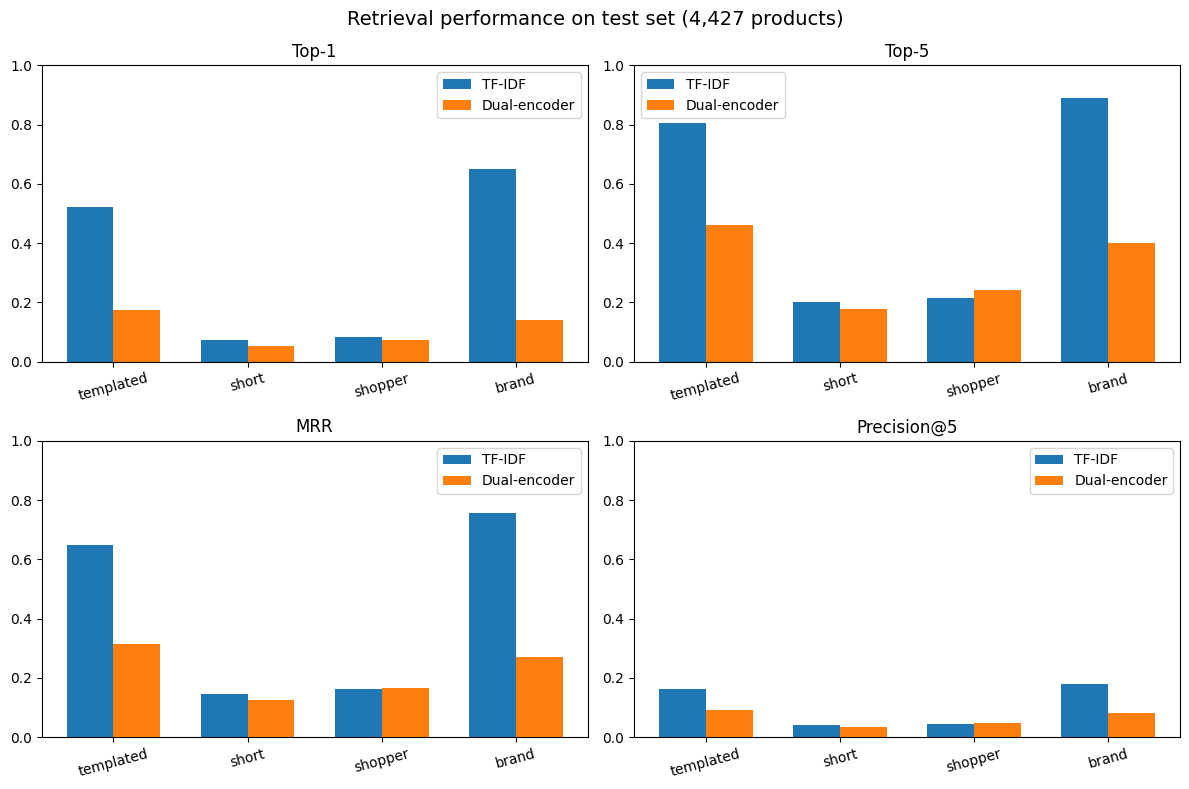

In [2]:
metrics = ['Top-1', 'Top-5', 'MRR', 'Precision@5']
query_types = results['Query type'].unique()
x = range(len(query_types))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    baseline = results[results['Model'] == 'TF-IDF'].set_index('Query type')[metric]
    dual = results[results['Model'].str.contains('Dual')].set_index('Query type')[metric]
    ax.bar([i - width/2 for i in x], [baseline.get(q, 0) for q in query_types], width, label='TF-IDF')
    ax.bar([i + width/2 for i in x], [dual.get(q, 0) for q in query_types], width, label='Dual-encoder')
    ax.set_xticks(list(x))
    ax.set_xticklabels(query_types, rotation=15)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Retrieval performance on test set (4,427 products)', fontsize=14)
plt.tight_layout()
plt.show()

## Evaluation protocol

- **Gallery:** held-out `test.csv` (4,427 products).
- **Queries:** each product generates a query from its own attributes (4 styles via `src/captions.py`).
- **Success:** the query's product ID appears in top-K among all test images.
- **Same rule** for TF-IDF and dual-encoder.

**Note:** Ablation charts below use **validation** Recall@K from development notebooks. The table and bar charts above use the **test** set (final numbers for our report).

In [3]:
# Where does dual-encoder beat TF-IDF? (shopper queries)
shopper = results[results['Query type'] == 'shopper'].set_index('Model')
compare = pd.DataFrame({
    'TF-IDF': shopper.loc['TF-IDF', ['Top-1', 'Top-5', 'MRR']],
    'Dual-encoder': shopper.loc[shopper.index.str.contains('Dual'), ['Top-1', 'Top-5', 'MRR']].iloc[0],
}).T.round(3)
display(compare)

print('Takeaway: TF-IDF wins Top-1 overall, but dual-encoder has higher Top-5 and MRR on shopper queries —')
print('it often surfaces the correct product in the top 5 even when rank 1 is wrong.')

,Top-1,Top-5,MRR
TF-IDF,0.084,0.216,0.161
Dual-encoder,0.074,0.241,0.167


Takeaway: TF-IDF wins Top-1 overall, but dual-encoder has higher Top-5 and MRR on shopper queries —
it often surfaces the correct product in the top 5 even when rank 1 is wrong.


## Experiment progression (v1 → v5)

During development we iterated through five model versions (notebooks in `richardson_experiment/`). Below: validation-set Recall@K from the ablation runs. The final unified test evaluation is in the table above.

See `notebooks/richardson_experiment/README.md` for the full notebook-by-notebook story.

,Setup,R@1,R@5,R@10
0,"v1 nb04 (template-trained, template query)",0.106,0.332,0.488
1,"v2 nb05 (expansion, template query)",0.080,0.271,0.425
2,"v2 nb05 (expansion, shopper query)",0.056,0.199,0.328
3,"v3 nb06 (rotation, template query)",0.068,0.247,0.387
4,"v3 nb06 (rotation, shopper query)",0.049,0.192,0.314
5,"v4 nb07 (pretrained text, template query)",0.208,0.523,0.668
6,"v4 nb07 (pretrained text, shopper query)",0.074,0.244,0.371
7,"v4 nb07 (pretrained text, short query)",0.054,0.183,0.277
8,"v4 nb07 (pretrained text, brand query)",0.155,0.438,0.593


,Setup,R@1,R@5,R@10
0,"v1 nb04 (scratch text, template query)",0.106,0.332,0.488
1,"v4 nb07 (pretrained text, template query)",0.208,0.523,0.668
2,"v4 nb07 (pretrained text, brand query)",0.155,0.438,0.593
3,"v4 nb07 (pretrained text, shopper query)",0.074,0.244,0.371
4,"v4 nb07 (pretrained text, short query)",0.054,0.183,0.277
5,"v5 nb08 (pretrained + rotation, template query)",0.155,0.438,0.599
6,"v5 nb08 (pretrained + rotation, brand query)",0.159,0.435,0.586
7,"v5 nb08 (pretrained + rotation, shopper query)",0.095,0.301,0.452
8,"v5 nb08 (pretrained + rotation, short query)",0.078,0.245,0.369


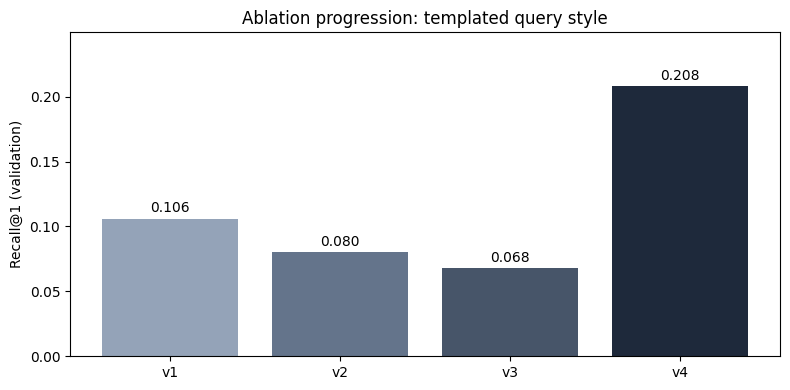

In [4]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from paths import ABLATIONS_DIR

v134 = pd.read_csv(ABLATIONS_DIR / 'v1_v2_v3_v4_comparison.csv')
final = pd.read_csv(ABLATIONS_DIR / 'final_comparison.csv')

display(v134.round(3))
display(final.round(3))

# v1 → v4 progression (template query)
template_rows = v134[v134['Setup'].str.contains('template query', case=False)]
labels = ['v1', 'v2', 'v3', 'v4']
r1 = template_rows['R@1'].values

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, r1, color=['#94a3b8', '#64748b', '#475569', '#1e293b'])
ax.set_ylabel('Recall@1 (validation)')
ax.set_title('Ablation progression: templated query style')
ax.set_ylim(0, max(r1) * 1.2)
for i, v in enumerate(r1):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Training curves (v4)

Loss curves from Richardson's final v4 training run (`07_pretrained_text_encoder.ipynb`). v4 was selected over v5 (pretrained text + caption rotation).

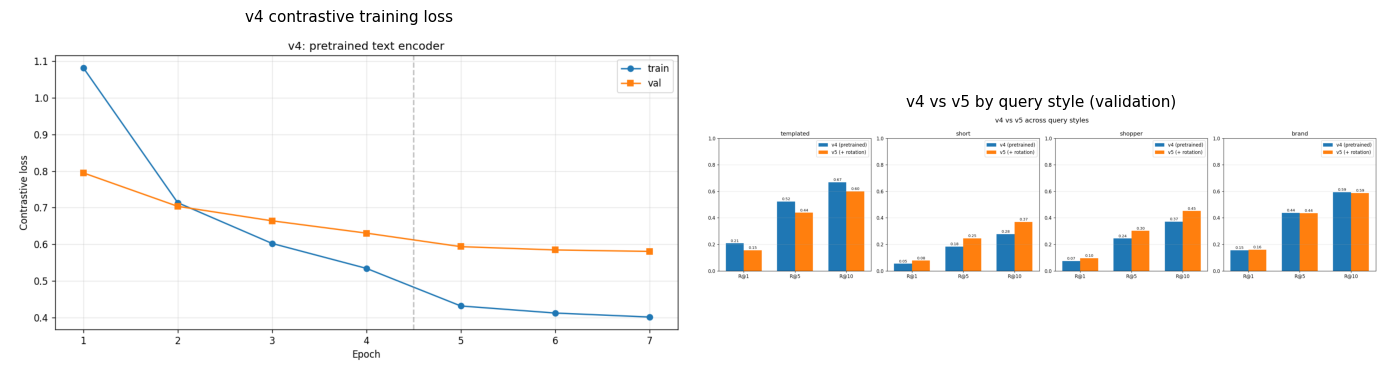

In [5]:
from PIL import Image

training_plots = [
    ('v4 contrastive training loss', PROJECT_ROOT / 'models/experiments/v4_loss_curve.png'),
    ('v4 vs v5 by query style (validation)', PROJECT_ROOT / 'models/experiments/v4_vs_v5_per_style.png'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (title, path) in zip(axes, training_plots):
    if path.exists():
        ax.imshow(Image.open(path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'Missing: {path.name}\nRe-run richardson_experiment/07', ha='center', va='center')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Query styles (examples)

Each test product gets a query built from its row. Four styles:

| Style | Example |
|---|---|
| **templated** | `A men navy blue shirts, for casual wear in fall. Turtle Check Men Navy Blue Shirt.` |
| **shopper** | `men's navy blue shirt` |
| **brand** | `Turtle Check Men Navy Blue Shirt` (product display name) |
| **short** | `navy shirt` |

In [ ]:
import sys
import numpy as np
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from captions import QUERY_GENERATORS
from config import TFIDF_MAX_FEATURES
from search import load_dual_encoder
from model import encode_images, encode_texts, resolve_image_path
from paths import TEST_EMBEDDINGS_PATH, WEIGHTS_PATH

test_df = pd.read_csv(PROJECT_ROOT / 'data/processed/test.csv')


def dual_rank(query, target_id, test_df, image_emb, text_encoder):
    q_emb = encode_texts(text_encoder, [query])
    sims = (q_emb @ image_emb.T).flatten()
    order = sims.argsort()[::-1]
    ids = test_df.iloc[order]['id'].values
    match = np.where(ids == target_id)[0]
    return int(match[0]) + 1 if len(match) else None


def plot_retrieval(query, target_id, test_df, image_emb, text_encoder, top_k=5, title_prefix=''):
    q_emb = encode_texts(text_encoder, [query])
    sims = (q_emb @ image_emb.T).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    fig, axes = plt.subplots(1, top_k, figsize=(3 * top_k, 3.2))
    if top_k == 1:
        axes = [axes]
    for ax, idx in zip(axes, top_idx):
        row = test_df.iloc[idx]
        img = Image.open(resolve_image_path(row['image_path'], PROJECT_ROOT))
        ax.imshow(img)
        ax.axis('off')
        suffix = '\n(correct)' if row['id'] == target_id else ''
        ax.set_title(str(row['productDisplayName'])[:30] + suffix, fontsize=8)

    rank = dual_rank(query, target_id, test_df, image_emb, text_encoder)
    rank_label = f'rank {rank}' if rank else 'not in top-5'
    plt.suptitle(f'{title_prefix}Query: {query}\nCorrect product {rank_label}', fontsize=10)
    plt.tight_layout()
    plt.show()
    return rank


def plot_side_by_side(query, target_id, test_df, image_emb, text_encoder, tfidf_matrix, vectorizer, top_k=5):
    q_emb = encode_texts(text_encoder, [query])
    dual_sims = (q_emb @ image_emb.T).flatten()
    dual_idx = dual_sims.argsort()[::-1][:top_k]

    q_vec = vectorizer.transform([query])
    tfidf_sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
    tfidf_idx = tfidf_sims.argsort()[::-1][:top_k]

    fig, axes = plt.subplots(2, top_k, figsize=(3 * top_k, 6))
    for col, idx in enumerate(tfidf_idx):
        row = test_df.iloc[idx]
        img = Image.open(resolve_image_path(row['image_path'], PROJECT_ROOT))
        axes[0, col].imshow(img)
        axes[0, col].axis('off')
        mark = '\n✓' if row['id'] == target_id else ''
        axes[0, col].set_title(str(row['productDisplayName'])[:26] + mark, fontsize=7)
    axes[0, 0].set_ylabel('TF-IDF', fontsize=11)

    for col, idx in enumerate(dual_idx):
        row = test_df.iloc[idx]
        img = Image.open(resolve_image_path(row['image_path'], PROJECT_ROOT))
        axes[1, col].imshow(img)
        axes[1, col].axis('off')
        mark = '\n✓' if row['id'] == target_id else ''
        axes[1, col].set_title(str(row['productDisplayName'])[:26] + mark, fontsize=7)
    axes[1, 0].set_ylabel('Dual-encoder', fontsize=11)

    plt.suptitle(f'Same query, same test gallery\n{query}', fontsize=10)
    plt.tight_layout()
    plt.show()


if not WEIGHTS_PATH.exists():
    print('Train first: python src/train.py')
else:
    model, text_encoder = load_dual_encoder()
    image_paths = [resolve_image_path(p, PROJECT_ROOT) for p in test_df['image_path']]
    if TEST_EMBEDDINGS_PATH.exists() and np.load(TEST_EMBEDDINGS_PATH).shape[0] == len(test_df):
        image_emb = np.load(TEST_EMBEDDINGS_PATH)
        print(f'Loaded cached embeddings: {TEST_EMBEDDINGS_PATH.name}')
    else:
        print('Encoding test gallery (~4k images, may take several minutes)...')
        image_emb = encode_images(model, image_paths)

    tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=TFIDF_MAX_FEATURES)
    tfidf_matrix = tfidf_vectorizer.fit_transform(test_df['product_text'].astype(str))
    print(f'Gallery ready: {len(test_df):,} products')

In [ ]:
if WEIGHTS_PATH.exists():
    demo_rows = {
        'templated': test_df.sample(1, random_state=11).iloc[0],
        'shopper': test_df.sample(1, random_state=22).iloc[0],
        'brand': test_df.sample(1, random_state=33).iloc[0],
        'short': test_df.sample(1, random_state=44).iloc[0],
    }

    for style, row in demo_rows.items():
        query = QUERY_GENERATORS[style](row)
        print(f'\n=== {style.upper()} ===')
        print('Target:', row['productDisplayName'])
        plot_retrieval(query, row['id'], test_df, image_emb, text_encoder)

## Success example (dual-encoder, templated query)

Scan test products until the dual-encoder returns the correct item at **rank 1** with a templated query.

In [ ]:
if WEIGHTS_PATH.exists():
    success_row = None
    success_query = None
    for _, row in test_df.sample(800, random_state=77).iterrows():
        query = QUERY_GENERATORS['templated'](row)
        if dual_rank(query, row['id'], test_df, image_emb, text_encoder) == 1:
            success_row, success_query = row, query
            break

    if success_row is not None:
        print('Target:', success_row['productDisplayName'])
        plot_retrieval(success_query, success_row['id'], test_df, image_emb, text_encoder, title_prefix='SUCCESS — ')
    else:
        print('No rank-1 templated hit in sample; re-run or increase sample size.')

## Head-to-head: TF-IDF vs dual-encoder (brand query)

Same query and test gallery. Brand queries favor TF-IDF because it matches product names in `product_text`.

In [ ]:
if WEIGHTS_PATH.exists():
    brand_row = test_df.sample(1, random_state=33).iloc[0]
    brand_query = QUERY_GENERATORS['brand'](brand_row)
    print('Target:', brand_row['productDisplayName'])
    print('Query:', brand_query)
    plot_side_by_side(
        brand_query, brand_row['id'], test_df, image_emb, text_encoder,
        tfidf_matrix, tfidf_vectorizer,
    )

## Failure cases & discussion

We scan a sample of test products for **shopper-style** queries (hardest for both models). Below: cases where the dual-encoder does not retrieve the correct product in the top 5.

**Why TF-IDF often wins:** it searches text against text (`product_text` includes JSON descriptions). The dual-encoder must match a text query to **images**, a harder cross-modal task.

In [ ]:
if WEIGHTS_PATH.exists():
    scan = test_df.sample(400, random_state=99)
    failures = []

    for _, row in scan.iterrows():
        query = QUERY_GENERATORS['shopper'](row)
        q_emb = encode_texts(text_encoder, [query])
        sims = (q_emb @ image_emb.T).flatten()
        top5_idx = sims.argsort()[::-1][:5]
        if row['id'] not in test_df.iloc[top5_idx]['id'].values:
            failures.append((row, query))

    print(f'Shopper-query failures in sample: {len(failures)} / {len(scan)}')
    dual_shopper = results.loc[
        (results['Model'].str.contains('Dual')) & (results['Query type'] == 'shopper'), 'Top-1'
    ].iloc[0]
    tfidf_shopper = results.loc[
        (results['Model'] == 'TF-IDF') & (results['Query type'] == 'shopper'), 'Top-1'
    ].iloc[0]
    print(f'Official test Top-1 — TF-IDF: {tfidf_shopper:.3f}, Dual-encoder: {dual_shopper:.3f}')

    for row, query in failures[:3]:
        print('\n--- Failure example ---')
        print('Query:', query)
        print('Target:', row['productDisplayName'])
        plot_retrieval(query, row['id'], test_df, image_emb, text_encoder)